In [2]:
import math
import random
import requests
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [8]:
def plt_img(plain_img, msg_img):
  f, ax = plt.subplots(1, 2, figsize=(12, 16))
  ax[0].imshow(plain_img)
  ax[1].imshow(msg_img)
  plt.show()

In [3]:
# A string
msg_str = "None of them noticed a large, tawny owl flutter past the window."

# A paragraph
msg_para = "Hermione: Are you sure that's a real spell? Well, it's not very \
good, is it? Of course I've only tried a few simple spells myself, and they've \
all worked for me. For example...{Hermione goes over and sits across from \
Harry. He points her hand at his glasses and Harry tenses} Oculus Reparo. {The \
glasses, which noseband is battered, are repaired. Harry takes them off, amazed.\
} That's better, isn't it? Holy Cricket, you're Harry Potter. I'm Hermione \
Granger...and you are...?"

# Two numbers
msg_num1 = 19
msg_num2 = 3

# A dataset
msg_data = [msg_str, msg_para, msg_num1, msg_num2]

# An image
url = "https://1.bp.blogspot.com/-O8FQac8ZU0U/XpVodd4zyCI/AAAAAAAAFeA/_gxAE-hJ4q8uuhbukYd6ugvprqfB11SmACK4BGAsYHg/tux.png"
plain_img = Image.open(requests.get(url, stream=True).raw)

# A dataframe
df = pd.DataFrame(index=range(-5, 6), columns=range(-5, 6))

In [1]:
import rsa

publicKey, privateKey = rsa.newkeys(256)

message = "Hello, World!"
encMessage = rsa.encrypt(message.encode(), publicKey)

print("original string: ", message)
print("encrypted string: ", encMessage)

decMessage = rsa.decrypt(encMessage, privateKey).decode()

print("decrypted string: ", decMessage)

original string:  Hello, World!
encrypted string:  b's\xa7\x91?\xe7/M\x88+\x8a\\I\x90\x91\xde\x87.\x9c\x8c\xa1L\x87SDB\xfd\x90\n]{\xc0 '
decrypted string:  Hello, World!


In [4]:
def generateKeys(n):
  (publicKey, privateKey) = rsa.newkeys(n)
  with open('publicKey.pem', 'wb') as p:
    p.write(publicKey.save_pkcs1('PEM'))
  with open('privateKey.pem', 'wb') as p:
    p.write(privateKey.save_pkcs1('PEM'))

In [5]:
def loadKeys():
  with open('publicKey.pem', 'rb') as p:
    publicKey = rsa.PublicKey.load_pkcs1(p.read())
  with open('privateKey.pem', 'rb') as p:
    privateKey = rsa.PrivateKey.load_pkcs1(p.read())
  return privateKey, publicKey

In [6]:
def decrypt(ciphertext, key):
  try:
    return rsa.decrypt(ciphertext, key).decode('ascii')
  except:
    return False

In [7]:
def verify(message, signature, key):
  try:
    return rsa.verify(message.encode('ascii'), signature, key,) == 'SHA-1'
  except:
    return False

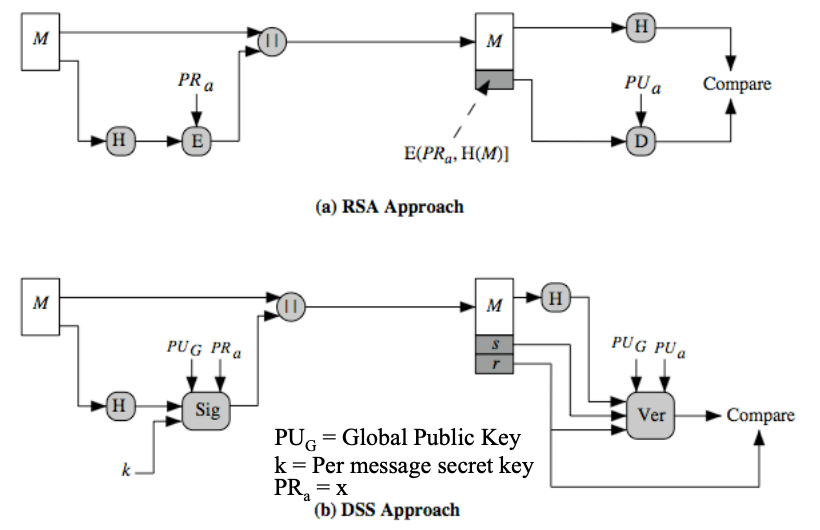

In [14]:
generateKeys(4096)

privateKey, publicKey = loadKeys()

In [15]:
for data in msg_data:
  data = str(data)
  print("Plain Text : " + data)
  print("Plain Text Size : " + str(len(data)))

  encMessage = rsa.encrypt(data.encode('ascii'), publicKey)
  print("Cipher Text : " + str(encMessage))
  print("Cipher Text Size : " + str(len(encMessage)))

  signature = rsa.sign(data.encode('ascii'), privateKey, 'SHA-1')

  #hash = rsa.compute_hash(data.encode(), 'SHA-1')
  #signature = rsa.sign_hash(hash, privateKey, 'SHA-1')

  print("Signature Text : " + str(signature))
  print("Signature Text Size : " + str(len(signature)))

  decMessage = decrypt(encMessage, privateKey)

  if decMessage:
    print("Decrypted Text : ", decMessage)
    print("Decrypted Text Size : ", str(len(decMessage)))
    if verify(decMessage, signature, publicKey):
      print("Successfully verified signature")
    else:
      print("The message signature could not be verified")
  else:
    print("Unable to decrypt the message.")
  
  print()

Plain Text : None of them noticed a large, tawny owl flutter past the window.
Plain Text Size : 64
Cipher Text : b'\x06\xd6!W\xb3W\xec\xb9\x8c!\x18{(t\xf0y\x9f\xcfd\xd5r\xd5\xc8\x907\xf1\x0e\xe4\xdc\xe7\xcf\x9b\xcb\xb3\xf0]\xd5g\xa8\xfdD<\xd5{\xed8@K@o!\xc2\r\xc4\xf0q!\xa4\x99\x07\xe6\xddQ[,E\xf4\x03\xde\xca`\xd4\x0b\xd2\xf4\xf4\x17\xc1l_\xa7\xa7\x11Oh\xd8\xb6\xd9\xf2=\'^ \xb8f:\x9e\x02\xa3\xa8\xbf\xeaA\xf3+\xce/\xd5&\x05\xf1\xc4_\x10x\xe9\xdf\x10.\'\xd9{Q\xbf\xb87S+?\x05IaZ]\xb2\x8d\xc5\xc2> \x04c\xef\xd0\xb9\x84\x1b\x0b9\xb8\xa0\xf3\xc8\xa2\xa3 \xc9m#3P\x07\xae\x9a\x11\x1a\x94\x0f&\xbe*~\x13.0\x89S\xe7\x06\xad\n\xc9|\xcd?\xfa\xbbw\xcd\xac\xfa\xb6\x08\xe1,\x9cK\x03\xa9w\xbc\x9d\t.-\xf1\xda\xaaY\xf3\x83\xe9\xeb\x04\xc9\xef\x1a\xb10m\xa1~\xdfC\xd9\xebe\xef\xaa\xc3\t\xd6\x07\xf0i\x11D\x17V\xaf\xfa\xb7\xaf{s\xc5\x08\tB<f\xf6\xd5R\xda\xae\xa9t\xbb\xfac\xf7\xd9`\xc1\x85\xd4e\xfc&\xbc(a\xcf\xe7\xd3Y\x0c\x04\xd5\x9f\xf3j"\xcd\xd6U\x00\xe1\'\x98\'d?\xcaoA\xf8\xcc\x993\xf4\x07\xc9\xe4\xbf\xdf\x

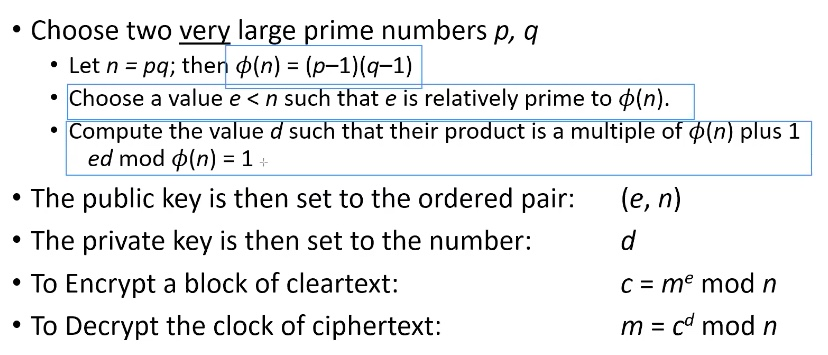

In [9]:
# primality check function
def is_prime(x):
	# TO DO

In [10]:
# generate random prime function
def generate_prime():
	# TO DO

In [11]:
# function to find gcd
def gcd(a, b):
	# TO DO

In [12]:
# function to find extended gcd
def egcd(a, b):
	# TO DO

In [13]:
# function to find modular inverse
def modinv(a,m):
	# TO DO

In [16]:
# choose 2 distinct primes p & q
# p = generate_prime()
# while True:
# 	q = generate_prime()
# 	if q != p:
# 		break

p = 17
q = 23

print("p = %d" % p)
print("q = %d" % q)

n = p * q
n1 = (p - 1) * (q - 1)

print("n = %d" % n)
print("n1 = %d" % n1)

p = 17
q = 23
n = 391
n1 = 352


In [17]:
# Choose 1 < e < φ(n), which is coprime to φ(n)
# e is public key exponent
r = random.randint(2,10) # For efficiency 2 < e < 100

while True:
	if gcd(r, n1) == 1:
			break
	else:
		r += 1

e = r
print("e = %d" % e)

# Compute d, the modular multiplicative inverse of e
# Private key exponent d
d = modinv(e, n1)
print("d = %d" % d)

e = 5
d = 141


In [18]:
m = 16 * 16

c = (m**e) % n
print("Encrypted message = %d" % c)

m1 = (c**d) % n
print("Decrypted message = %d" % m1)

Encrypted message = 358
Decrypted message = 256


In [19]:
string = "Super secret message!!"
cipher = []
plain = []

In [20]:
# encryption

for c in string:
  cipher.append(chr((ord(c)**e)%n))
print(''.join(cipher))

ģĴ}©ēŸs©?ē©űŸq©ssx©ËË


In [21]:
#decryption

for c in cipher:
  plain.append(chr((ord(c)**d)%n))
print(''.join(plain))

Super secret message!!


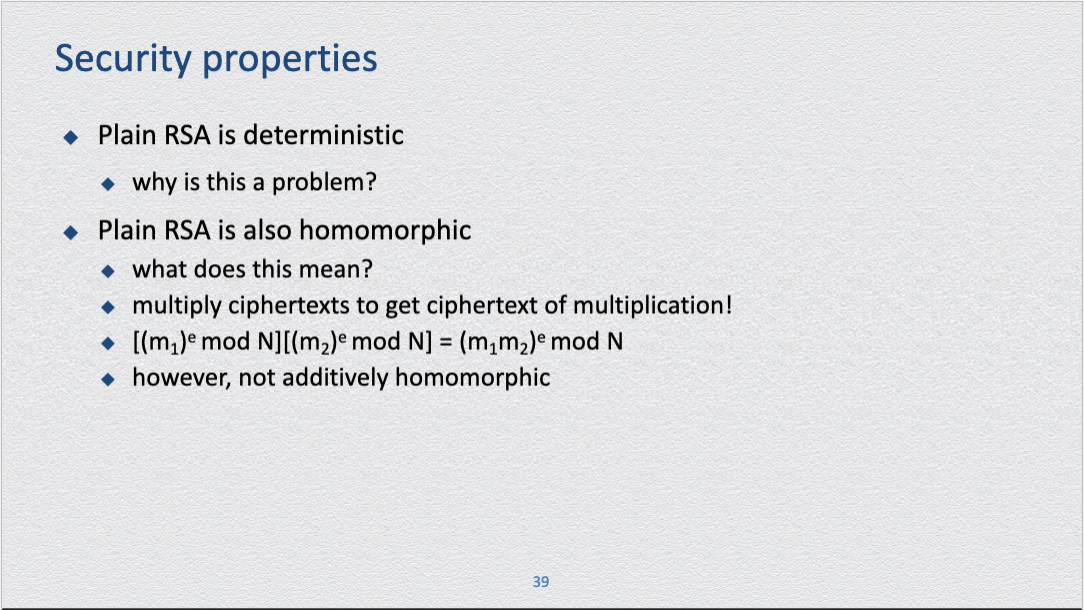

In [22]:
msg_img = Image.open(requests.get(url, stream=True).raw)
w, h = msg_img.size

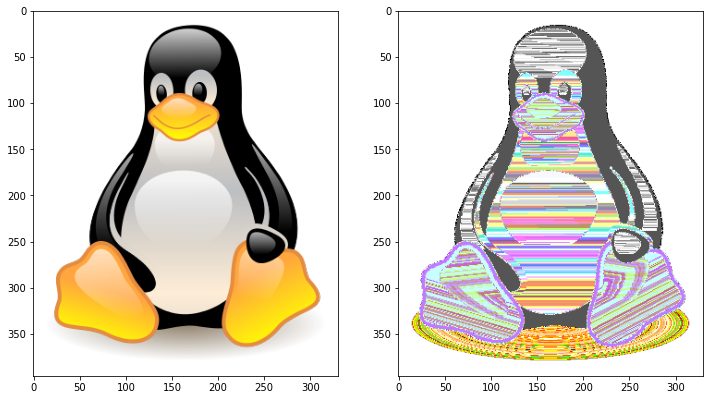

In [23]:
pix = msg_img.load()

for i in range(w):
  for j in range(h):
    r, g, b, p = pix[i, j]
    r = (r**e) % n
    g = (g**e) % n
    b = (b**e) % n
    p = (p**e) % n
    pix[i, j] = (r, g, b, p)

plt_img(plain_img, msg_img)

In [24]:
# addition

for i in range(-5, 6):
  for j in range(-5, 6):
    ciph_num1 = (i ** e) % n
    ciph_num2 = (j ** e) % n
    
    padd = i + j
    eadd = ciph_num1 + ciph_num2
    dadd = (eadd ** d) % n

    if padd == dadd:
      df.at[i, j] = ""
    else:
      df.at[i, j] = dadd

print(df)

     -5   -4   -3   -2   -1   0    1    2    3    4    5 
-5  384   67  325  122  236  386  174  188   77  244     
-4   67  229  247  121  388  387   73  143    1       147
-3  325  247   74  277  347  388  387   79       390  314
-2  122  121  277  310  256  389  267       312  248  203
-1  236  388  347  256  155  390       124    4  318  217
0   386  387  388  389  390                              
1   174   73  387  267            236  135   44    3  155
2   188  143   79       124       135   81  114  270  269
3    77    1       312    4        44  114  317  144   66
4   244       390  248  318         3  270  144  162  324
5        147  314  203  217       155  269   66  324    7


In [25]:
# multiplication

for i in range(-5, 6):
  for j in range(-5, 6):
    ciph_num1 = (i ** e) % n
    ciph_num2 = (j ** e) % n

    pmul = i * j
    emul = ciph_num1 * ciph_num2
    dmul = (emul ** d) % n

    if pmul == dmul:
      df.at[i, j] = ""
    else:
      df.at[i, j] = dmul

print(df)

     -5   -4   -3   -2   -1 0    1    2    3    4    5 
-5                              386  381  376  371  366
-4                              387  383  379  375  371
-3                              388  385  382  379  376
-2                              389  387  385  383  381
-1                              390  389  388  387  386
0                                                      
1   386  387  388  389  390                            
2   381  383  385  387  389                            
3   376  379  382  385  388                            
4   371  375  379  383  387                            
5   366  371  376  381  386                            


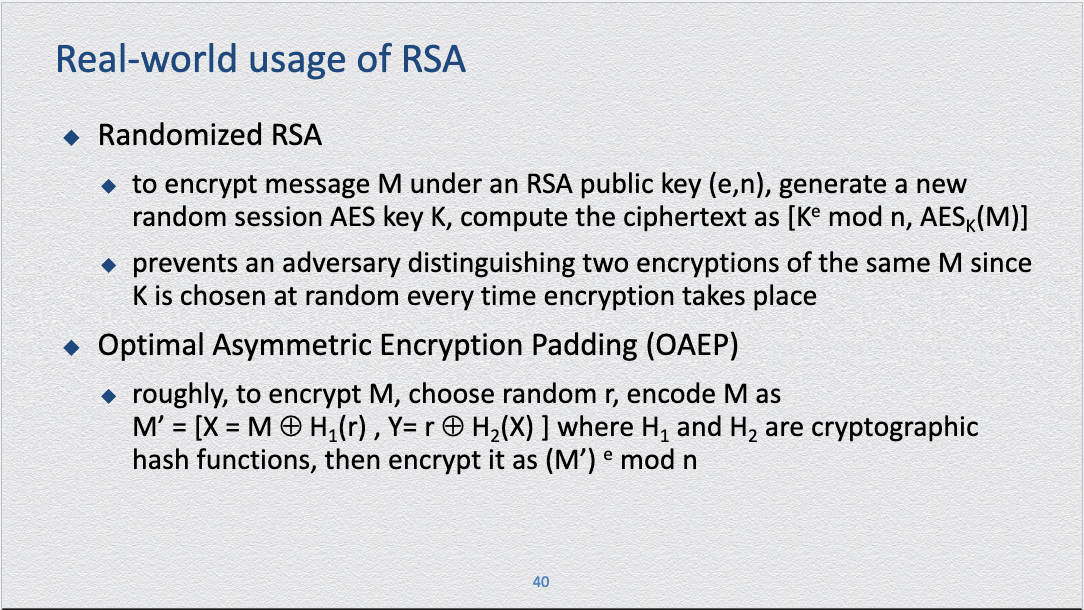

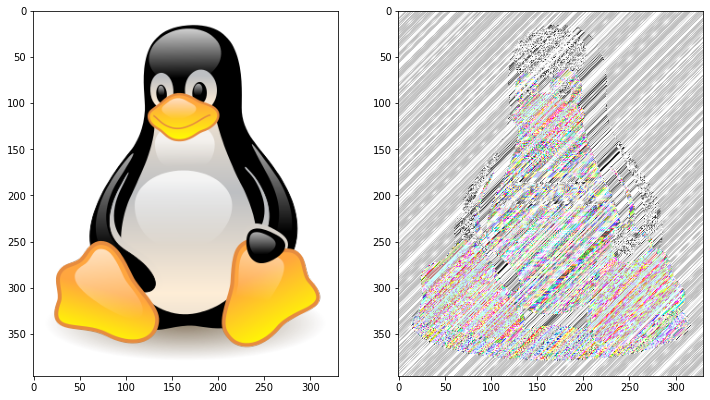

In [26]:
pix = msg_img.load()

for i in range(w):
  for j in range(h):
    r, g, b, p = pix[i, j]
    r = ((r+i+j)**e) % n
    g = ((g+i+j)**e) % n
    b = ((b+i+j)**e) % n
    p = ((p+i+j)**e) % n
    pix[i, j] = (r, g, b, p)

plt_img(plain_img, msg_img)

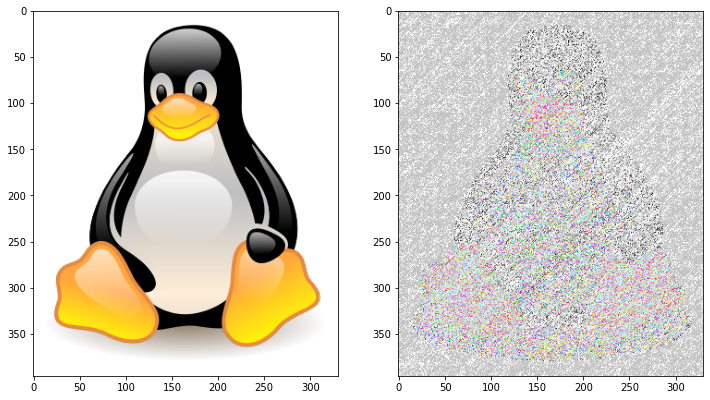

In [27]:
pix = msg_img.load()

for i in range(w):
  for j in range(h):
    r, g, b, p = pix[i, j]
    pad = random.randint(2,10)
    r = ((r+pad)**e) % n
    g = ((g+pad)**e) % n
    b = ((b+pad)**e) % n
    p = ((p+pad)**e) % n
    pix[i, j] = (r, g, b, p)

plt_img(plain_img, msg_img)